In [ ]:
!pip install xgboost shap joblib

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score

                )

from xgboost import XGBClassifier

import shap
import joblib

In [ ]:
df = pd.read_csv("/content/wsn_landslide_data.csv")

df.head()

,Rainfall_mm,Slope_Angle,Soil_Saturation,Vegetation_Cover,Rainfall_3Day,Rainfall_7Day,Aspect,Elevation_m,NDVI_Index,Land_Use_Urban,...,Soil_Type_Silt,Soil_Type_Clay,Pore_Water_Pressure_kPa,Soil_Moisture_Content,Microseismic_Activity,Acoustic_Emission_dB,Soil_Strain,Soil_Temperature_C,TDR_Reflection_Index,Label
0,164.695364,59.783332,0.821479,0.107339,260.138381,79.297169,346.674199,733.776448,0.191948,1,...,1,0,133.943194,0.143732,0.290945,51.021834,0.005167,22.760036,0.799847,1
1,34.908086,15.153084,0.100428,0.960150,510.295547,247.923576,104.462371,467.708643,0.798321,1,...,0,1,90.788608,0.266484,0.651758,39.837282,0.003443,15.558373,1.181071,0
2,38.761727,13.135384,0.286526,0.833608,297.730266,194.327012,336.671287,1880.826807,0.479456,1,...,0,1,83.041150,0.129426,0.440714,68.902366,0.009999,6.205760,1.184971,0
3,32.199977,10.674734,0.255230,0.847569,231.640610,295.139546,300.742864,964.080336,-0.084314,1,...,1,0,196.089305,0.240198,0.794001,80.196960,0.003850,25.486545,0.677944,0
4,218.114032,48.839269,0.720071,0.018383,330.278249,301.288824,155.550502,165.699102,0.810869,0,...,1,1,106.778890,0.345724,0.009160,99.919786,0.003061,7.270319,0.882642,1


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9864
Columns: 35


In [ ]:
print(df.columns.tolist())

['Rainfall_mm', 'Slope_Angle', 'Soil_Saturation', 'Vegetation_Cover', 'Rainfall_3Day', 'Rainfall_7Day', 'Aspect', 'Elevation_m', 'NDVI_Index', 'Land_Use_Urban', 'Land_Use_Forest', 'Land_Use_Agriculture', 'Earthquake_Activity', 'Proximity_to_Water', 'Distance_to_Road_m', 'Temperature_C', 'Humidity_percent', 'Soil_pH', 'Clay_Content', 'Sand_Content', 'Silt_Content', 'Soil_Erosion_Rate', 'Historical_Landslide_Count', 'Soil_Type_Gravel', 'Soil_Type_Sand', 'Soil_Type_Silt', 'Soil_Type_Clay', 'Pore_Water_Pressure_kPa', 'Soil_Moisture_Content', 'Microseismic_Activity', 'Acoustic_Emission_dB', 'Soil_Strain', 'Soil_Temperature_C', 'TDR_Reflection_Index', 'Label']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9864 entries, 0 to 9863
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Rainfall_mm                 9864 non-null   float64
 1   Slope_Angle                 9864 non-null   float64
 2   Soil_Saturation             9864 non-null   float64
 3   Vegetation_Cover            9864 non-null   float64
 4   Rainfall_3Day               9864 non-null   float64
 5   Rainfall_7Day               9864 non-null   float64
 6   Aspect                      9864 non-null   float64
 7   Elevation_m                 9864 non-null   float64
 8   NDVI_Index                  9864 non-null   float64
 9   Land_Use_Urban              9864 non-null   int64  
 10  Land_Use_Forest             9864 non-null   int64  
 11  Land_Use_Agriculture        9864 non-null   int64  
 12  Earthquake_Activity         9864 non-null   float64
 13  Proximity_to_Water          9864 

In [ ]:
df.describe()

,Rainfall_mm,Slope_Angle,Soil_Saturation,Vegetation_Cover,Rainfall_3Day,Rainfall_7Day,Aspect,Elevation_m,NDVI_Index,Land_Use_Urban,...,Soil_Type_Silt,Soil_Type_Clay,Pore_Water_Pressure_kPa,Soil_Moisture_Content,Microseismic_Activity,Acoustic_Emission_dB,Soil_Strain,Soil_Temperature_C,TDR_Reflection_Index,Label
count,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,...,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000
mean,125.643618,36.023345,0.524998,0.476049,298.324654,503.397364,179.656854,1554.277930,0.401557,0.503751,...,0.495235,0.503143,109.870150,0.300515,0.505180,65.249223,0.005021,17.511643,0.999273,0.502737
std,105.885846,25.150113,0.333087,0.341999,174.136992,287.807884,103.635389,830.193051,0.290701,0.500011,...,0.500003,0.500015,51.985999,0.114771,0.288668,20.165504,0.002866,7.191836,0.289470,0.500018
min,0.000582,5.000792,0.100032,0.000054,0.010042,0.008432,0.097244,100.377033,-0.099820,0.000000,...,0.000000,0.000000,20.048630,0.100006,0.000057,30.013652,0.000102,5.000212,0.500273,0.000000
25%,24.921180,12.311669,0.199151,0.150170,145.876834,257.167899,90.790915,833.122929,0.147099,0.000000,...,0.000000,0.000000,64.808859,0.202149,0.259342,47.932454,0.002486,11.297557,0.748873,0.000000
50%,99.996551,29.998160,0.499968,0.449941,295.410901,508.771270,179.345879,1560.377189,0.404669,1.000000,...,0.000000,1.000000,110.251356,0.299458,0.505641,65.609339,0.005023,17.551125,0.995237,1.000000
75%,227.181479,59.678277,0.850183,0.804152,452.111577,751.552823,269.961378,2272.900742,0.658994,1.000000,...,1.000000,1.000000,154.615202,0.398911,0.756698,82.978049,0.007499,23.644164,1.252241,1.000000
max,299.985147,79.987824,0.999937,0.999970,599.983288,999.939696,359.888356,2999.637788,0.899858,1.000000,...,1.000000,1.000000,199.971266,0.499924,0.999876,99.993756,0.009999,29.995773,1.499927,1.000000


In [ ]:
df.isnull().sum()

,0
Rainfall_mm,0
Slope_Angle,0
Soil_Saturation,0
Vegetation_Cover,0
Rainfall_3Day,0
Rainfall_7Day,0
Aspect,0
Elevation_m,0
NDVI_Index,0
Land_Use_Urban,0


In [ ]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [ ]:
print(df["Label"].value_counts())
print(df["Label"].value_counts(normalize=True))

Label
1    4959
0    4905
Name: count, dtype: int64
Label
1    0.502737
0    0.497263
Name: proportion, dtype: float64


In [ ]:
print("Unique labels:")
print(sorted(df["Label"].unique()))

Unique labels:
[np.int64(0), np.int64(1)]


In [ ]:
features = [
      "Rainfall_mm",
       "Rainfall_3Day",
        "Rainfall_7Day",
         "Slope_Angle",
         "Elevation_m",
          "Soil_Saturation",
          "Historical_Landslide_Count",
          "Pore_Water_Pressure_kPa",
          "Soil_Moisture_Content",
          "Microseismic_Activity",
          "Acoustic_Emission_dB",
          "Soil_Strain",
          "Soil_Erosion_Rate",
          "NDVI_Index",
          "Vegetation_Cover",
          "Distance_to_Road_m",
          "Proximity_to_Water",
          "Earthquake_Activity",
          "TDR_Reflection_Index"
                ]

X = df[features]
y = df["Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (9864, 19)
y shape: (9864,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
      X,
      y,
      test_size=0.20,
      random_state=42,
      stratify=y
                      )

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 7891
Testing samples: 1973


In [ ]:
model = XGBClassifier(
      n_estimators=300,
          max_depth=6,
              learning_rate=0.05,
                  subsample=0.8,
                      colsample_bytree=0.8,
                          objective="binary:logistic",
                              eval_metric="logloss",
                                  random_state=42
                                  )

model.fit(X_train, y_train)

print("Model training completed.")


Model training completed.


In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 97.82 %

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       981
           1       0.98      0.97      0.98       992

    accuracy                           0.98      1973
   macro avg       0.98      0.98      0.98      1973
weighted avg       0.98      0.98      0.98      1973



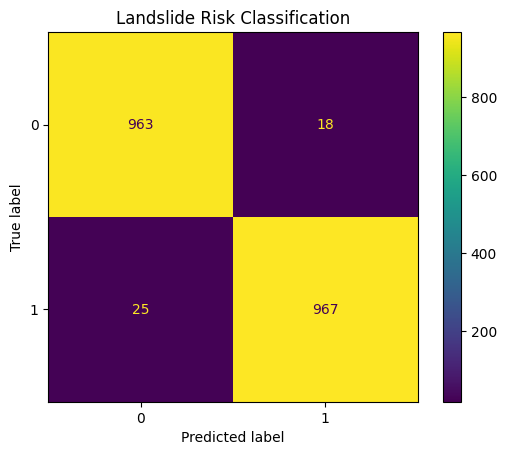

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
    )

disp.plot()
plt.title("Landslide Risk Classification")
plt.show()

Rainfall_mm                   0.567618
Soil_Saturation               0.141655
Slope_Angle                   0.073177
Vegetation_Cover              0.017940
Distance_to_Road_m            0.014500
Historical_Landslide_Count    0.014468
NDVI_Index                    0.013919
Elevation_m                   0.013847
Proximity_to_Water            0.013777
Rainfall_3Day                 0.013499
Pore_Water_Pressure_kPa       0.013452
TDR_Reflection_Index          0.013377
Microseismic_Activity         0.013251
Rainfall_7Day                 0.013165
Acoustic_Emission_dB          0.012692
Earthquake_Activity           0.012682
Soil_Moisture_Content         0.012521
Soil_Erosion_Rate             0.012323
Soil_Strain                   0.012137
dtype: float32


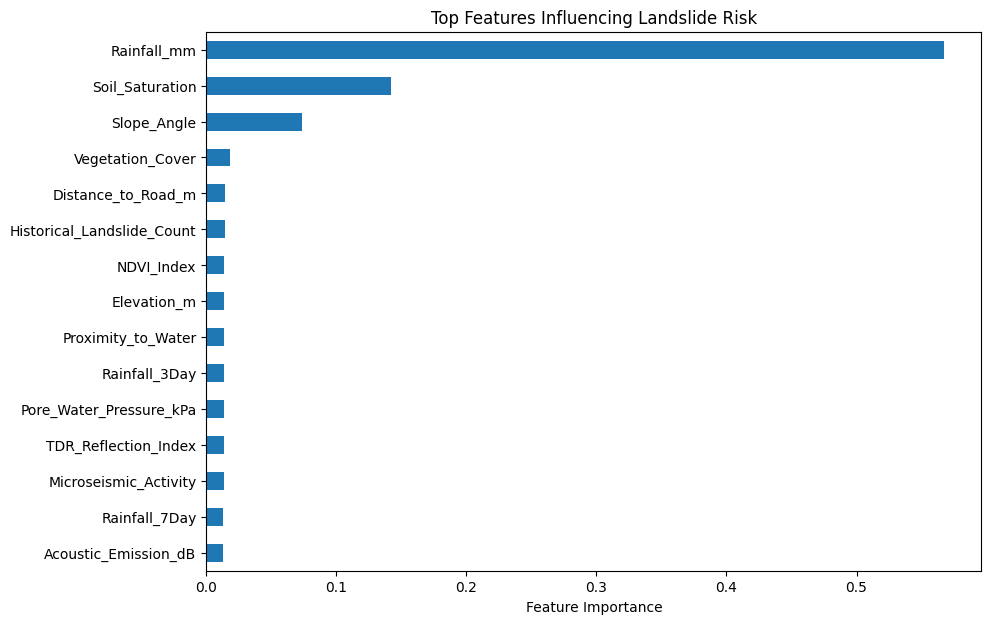

In [ ]:
importance = pd.Series(
      model.feature_importances_,
          index=features
          ).sort_values(ascending=False)

print(importance)

plt.figure(figsize=(10, 7))
importance.head(15).sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.title("Top Features Influencing Landslide Risk")
plt.show()


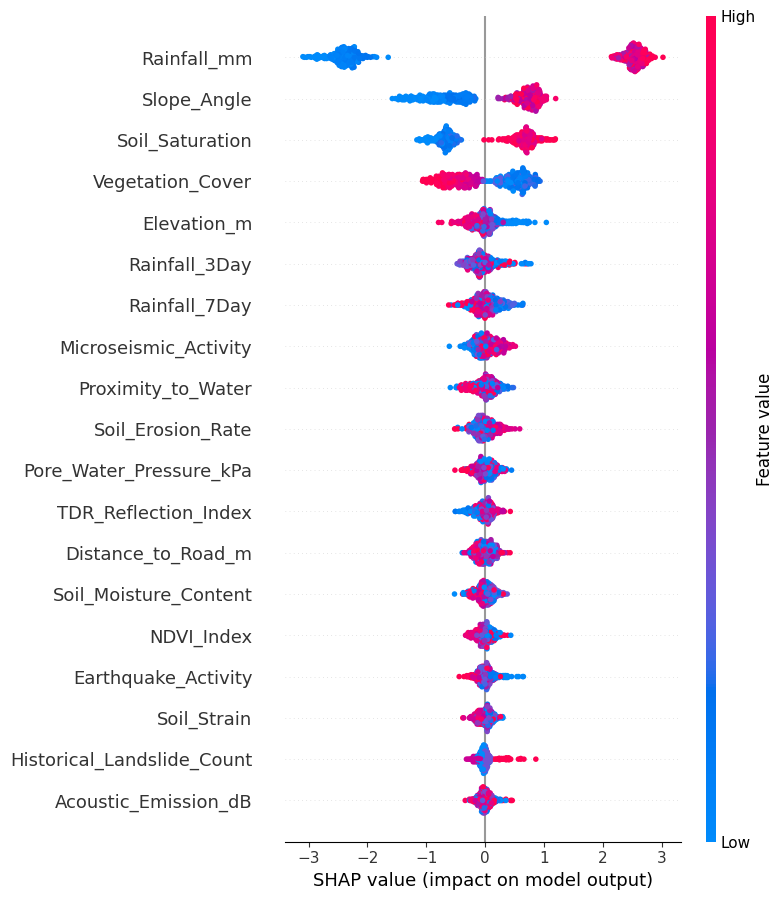

In [ ]:
explainer = shap.TreeExplainer(model)

X_sample = X_test.iloc[:500]

shap_values = explainer.shap_values(X_sample)

shap.summary_plot(
    shap_values,
        X_sample
        )

In [ ]:
def risk_level_from_score(score):

      if score < 25:
              return "LOW"

      elif score < 50:
              return "MODERATE"

      elif score < 75:
              return "HIGH"

      else:
              return "CRITICAL"

In [ ]:
def predict_risk(input_data):

             probability = model.predict_proba(input_data)[0]


             risk_probability = probability[1]

             risk_score = int(round(risk_probability * 100))

             risk_level = risk_level_from_score(risk_score)

             confidence = float(max(probability))

             return {
                  "risk_score": risk_score,
                  "risk_probability": round(float(risk_probability), 3),
                  "risk_level": risk_level,
                  "confidence": round(confidence, 3)
                                                                  }

In [ ]:
input_data = X_test.iloc[[0]]

result = predict_risk(input_data)

print(result)

{'risk_score': 4, 'risk_probability': 0.035, 'risk_level': 'LOW', 'confidence': 0.965}


In [ ]:
def get_top_factors(input_data, top_n=5):

      shap_result = explainer(input_data)

      values = shap_result.values[0]

      factor_df = pd.DataFrame({
                      "factor": features,
                              "contribution": values
                                  })

      factor_df["abs_contribution"] = (
                       factor_df["contribution"].abs()
                                                  )

      factor_df = factor_df.sort_values(
                            "abs_contribution",
                             ascending=False
                                                 )

      return factor_df.head(top_n)

In [ ]:
sample = X_test.iloc[[0]]

print(sample)

      Rainfall_mm  Rainfall_3Day  Rainfall_7Day  Slope_Angle  Elevation_m  \
5863    13.512385     104.123519     716.426989    19.806501  1547.914492   

      Soil_Saturation  Historical_Landslide_Count  Pore_Water_Pressure_kPa  \
5863         0.236842                           0                95.102279   

      Soil_Moisture_Content  Microseismic_Activity  Acoustic_Emission_dB  \
5863               0.245255               0.560293             34.480078   

      Soil_Strain  Soil_Erosion_Rate  NDVI_Index  Vegetation_Cover  \
5863     0.004707           47.29234    0.349026          0.603909   

      Distance_to_Road_m  Proximity_to_Water  Earthquake_Activity  \
5863          880.396445            0.342873              5.53433   

      TDR_Reflection_Index  
5863              0.526994  


In [ ]:
top_factors = get_top_factors(sample)

display(top_factors)

,factor,contribution,abs_contribution
0,Rainfall_mm,-2.537010,2.537010
5,Soil_Saturation,-0.672458,0.672458
3,Slope_Angle,-0.225863,0.225863
8,Soil_Moisture_Content,0.224156,0.224156
15,Distance_to_Road_m,-0.218755,0.218755


In [ ]:
top_factors_json = [
      {
              "factor": row["factor"],
              "contribution": round(
                      float(row["contribution"]), 3
                                          )
                                              }
      for _, row in top_factors.iterrows()
                                                  ]

print(top_factors_json)


[{'factor': 'Rainfall_mm', 'contribution': -2.537}, {'factor': 'Soil_Saturation', 'contribution': -0.672}, {'factor': 'Slope_Angle', 'contribution': -0.226}, {'factor': 'Soil_Moisture_Content', 'contribution': 0.224}, {'factor': 'Distance_to_Road_m', 'contribution': -0.219}]


In [ ]:
model
X_test
features
explainer
risk_level_from_score

<function __main__.risk_level_from_score(score)>

In [ ]:
print("Model:", type(model))
print("X_test:", X_test.shape)
print("Features:", len(features))
print("Explainer:", type(explainer))

Model: <class 'xgboost.sklearn.XGBClassifier'>
X_test: (1973, 19)
Features: 19
Explainer: <class 'shap.explainers._tree.TreeExplainer'>


In [ ]:
def test():
      print("It works!")

      test()

In [ ]:
def bhuskhalan_prediction(input_data):
      probability = model.predict_proba(input_data)[0]
      risk_probability = float(probability[1])
      risk_score = int(round(risk_probability * 100))
      risk_level = risk_level_from_score(risk_score)
      confidence = float(max(probability))

      return {
             "risk_score": risk_score,
             "risk_probability": round(risk_probability, 3),
             "risk_level": risk_level,
             "confidence": round(confidence, 3)
                                                              }

In [ ]:
sample = X_test.iloc[[0]]
display(sample)

,Rainfall_mm,Rainfall_3Day,Rainfall_7Day,Slope_Angle,Elevation_m,Soil_Saturation,Historical_Landslide_Count,Pore_Water_Pressure_kPa,Soil_Moisture_Content,Microseismic_Activity,Acoustic_Emission_dB,Soil_Strain,Soil_Erosion_Rate,NDVI_Index,Vegetation_Cover,Distance_to_Road_m,Proximity_to_Water,Earthquake_Activity,TDR_Reflection_Index
5863,13.512385,104.123519,716.426989,19.806501,1547.914492,0.236842,0,95.102279,0.245255,0.560293,34.480078,0.004707,47.29234,0.349026,0.603909,880.396445,0.342873,5.53433,0.526994


In [ ]:
result = bhuskhalan_prediction(sample)

print(result)

{'risk_score': 4, 'risk_probability': 0.035, 'risk_level': 'LOW', 'confidence': 0.965, 'risk_trend': 'NOT_AVAILABLE', 'top_factors': [{'factor': 'Rainfall_mm', 'contribution': -2.537}, {'factor': 'Soil_Saturation', 'contribution': -0.672}, {'factor': 'Slope_Angle', 'contribution': -0.226}]}


In [ ]:
print("=" * 45)
print("        BHUSKHALAN AI RISK REPORT")
print("=" * 45)

print(f"Risk Score       : {result['risk_score']}/100")
print(f"Risk Probability : {result['risk_probability'] * 100:.1f}%")
print(f"Risk Level       : {result['risk_level']}")
print(f"Confidence       : {result['confidence'] * 100:.1f}%")


print("\nTop Contributing Factors:")

for i, factor in enumerate(result["top_factors"], 1):
    print(
            f"{i}. {factor['factor']} "
                    f"({factor['contribution']})"
                        )

print("=" * 45)

        BHUSKHALAN AI RISK REPORT
Risk Score       : 4/100
Risk Probability : 3.5%
Risk Level       : LOW
Confidence       : 96.5%

Top Contributing Factors:
1. Rainfall_mm (-2.537)
2. Soil_Saturation (-0.672)
3. Slope_Angle (-0.226)


In [ ]:
def calculate_risk_trend(previous_score, current_score):

      difference = current_score - previous_score

      if difference >= 5:
                  return "INCREASING"

      elif difference <= -5:
                  return "DECREASING"

      else:
                  return "STABLE"

In [ ]:
previous_score = 65
current_score = result["risk_score"]

trend = calculate_risk_trend(
    previous_score,
        current_score
        )

print("Risk Trend:", trend)

Risk Trend: DECREASING


In [ ]:
joblib.dump(model, "bhuskhalan_xgboost_model.pkl")

print("Model saved successfully.")

Model saved successfully.
